In [34]:
# Exploratory Data Analysis for Startup Success

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(np.__version__)
print(pd.__version__)


2.4.6
3.0.5


## Load and inspect the data


In [35]:
# Loading the raw startup data
df_main = pd.read_csv(r"C:\Users\mklad\Desktop\Startup_Investment_App\Data\raw\big_startup_secsees_dataset.csv")


In [36]:
#checking the basics
print("Rows: ", df_main.shape[0])
print("Columns: ",df_main.shape[1])
print(df_main.columns)
print(df_main.dtypes)

Rows:  66368
Columns:  14
Index(['permalink', 'name', 'homepage_url', 'category_list',
       'funding_total_usd', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'founded_at', 'first_funding_at',
       'last_funding_at'],
      dtype='str')
permalink              str
name                   str
homepage_url           str
category_list          str
funding_total_usd      str
status                 str
country_code           str
state_code             str
region                 str
city                   str
funding_rounds       int64
founded_at             str
first_funding_at       str
last_funding_at        str
dtype: object


In [37]:
#Data Preview
df_main.head()

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


## Data quality and duplicate checks


In [38]:
#Now checking the data quality
df_main['founded_at'].isnull().sum()
#founding year agar missing ho to bhi hamare paas more than 50+ entries hai toh uss par kaam karte h
df_main[df_main['founded_at'].isnull()]


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
5,/organization/01games-technology,01Games Technology,http://www.01games.hk/,Games,41250,operating,HKG,NaN,Hong Kong,Hong Kong,1,NaN,2014-07-01,2014-07-01
10,/organization/1-4-all,1-4 All,NaN,Entertainment|Games|Software,-,operating,USA,NC,NC - Other,Connellys Springs,1,NaN,2013-04-21,2013-04-21
28,/organization/100du-tv,100du.tv,http://www.100du.com,Hospitality,3000000,operating,CHN,23,Shanghai,Shanghai,2,NaN,2008-01-07,2010-08-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66351,/organization/zynergy-projects-services,Zynergy Projects & Services,http://www.zynergygroup.net/,Clean Technology,-,operating,IND,25,Chennai,Chennai,1,NaN,2015-08-19,2015-08-19
66359,/organization/zyrra,Zyrra,http://www.zyrra.com,E-Commerce,1510500,operating,USA,MA,Boston,Cambridge,4,NaN,2010-10-21,2012-10-18
66360,/organization/zystor,Zystor,http://www.zystor.com,Biotechnology,8500000,acquired,USA,WI,Milwaukee,Milwaukee,1,NaN,2004-12-16,2004-12-16
66363,/organization/zznode-science-and-technology-co...,ZZNode Science and Technology,http://www.zznode.com,Enterprise Software,1587301,operating,CHN,22,Beijing,Beijing,1,NaN,2012-04-01,2012-04-01


In [39]:
#now checking for duplicate values 
#unique factor will be name or link

df_main[df_main['name'].duplicated()]
#running this gives us 265 duplicates based on name so we will delete them inplace
#but but but we don't directly work on the original dataframe so we will make a copy first

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
282,/organization/3divaz-3,3DIVAZ,http://www.3divaz.ch/Home,NaN,202250.031601567,operating,CHE,1,CHE - Other,Wildegg,1,2014-07-01,2015-11-01,2015-11-01
1527,/organization/adtena-2,Adtena,http://adtena.com,NaN,60000,closed,NaN,NaN,NaN,NaN,1,2014-11-15,2015-04-21,2015-04-21
1996,/organization/agora-6,Agora,https://www.agora.co,Android|Apps|Internet|Mobile,-,operating,USA,NY,New York City,New York,2,2013-07-01,2014-04-01,2014-12-01
3006,/organization/amicus-co,Amicus,http://www.amicus.co,Apps|Mobile|Mobile Commerce,18015,operating,IND,7,New Delhi,New Delhi,2,2015-01-01,2015-04-15,2015-04-22
3091,/organization/amplitude-2,Amplitude,http://amplitude-technologies.com/,Electronics,39079461,operating,FRA,A8,Ã‰vry,Évry,1,2001-01-01,2012-01-25,2012-01-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64571,/organization/wunder-3,Wunder,NaN,Alumni,41250,operating,NaN,NaN,NaN,NaN,1,NaN,2015-08-01,2015-08-01
64572,/organization/wundercar,Wunder,http://www.wunder.org,Apps|Emerging Markets|Marketplaces|Mobile Comm...,-,operating,DEU,4,Hamburg,Hamburg,3,2013-11-01,2013-12-23,2015-06-15
65799,/organization/zenpayroll,Gusto,https://gusto.com/,Financial Services|Personal Finance|Software,86100000,operating,USA,CA,SF Bay Area,San Francisco,4,2011-01-01,2012-02-01,2015-04-06
65899,/organization/zestyapp,Zesty,http://www.zesty.com/,Health and Wellness|Logistics|Organic Food|Spe...,23264207,operating,USA,CA,SF Bay Area,San Francisco,2,2013-11-04,2014-07-15,2015-07-10


## Initial cleaning and feature engineering


In [40]:
# Make a copy so the original raw dataframe is not changed
df = df_main.copy()
df.head()


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


In [41]:
#dropping unnecessary columns
df = df.drop(columns = ['homepage_url', 'permalink'])
df.head()

,name,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,#fame,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,:Qounter,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,"(THE) ONE of THEM,Inc.",Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,004 Technologies,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


In [42]:
# Rename columns used later in the analysis
df = df.rename(columns={
    "category_list": "Industry",
    "funding_total_usd": "Funding",
    "founded_at": "Founding_year"
})

# Drop duplicate startup names
df = df.drop_duplicates(subset=["name"])


In [43]:
# Now we have to fill Founding_year where it is missing.
# We estimate it using the average time between founding and first funding.

# Apart from status we will also use the age of the startup.
df['Founding_year'] = pd.to_datetime(df['Founding_year'], errors='coerce')
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'], errors='coerce')

df['funding_diff_days'] = (df['first_funding_at'] - df['Founding_year']).dt.days
# The source data is date-only. A whole-day gap preserves the datetime64[us] precision
# needed for historical dates such as year 1015.
avg_diff_days = int(round(df['funding_diff_days'].dropna().mean()))

# Only impute missing founding dates with usable first-funding dates.
# This avoids subtracting from a few extreme historical dates that can exceed pandas' date range.
missing_founding = df['Founding_year'].isna()
valid_first_funding = (
    df['first_funding_at'].notna()
    & (df['first_funding_at'] >= pd.Timestamp('1990-01-01'))
)
impute_mask = missing_founding & valid_first_funding

df.loc[impute_mask, 'Founding_year'] = (
    df.loc[impute_mask, 'first_funding_at']
    - pd.Timedelta(days=avg_diff_days)
)

# Now calculate startup age
df['company_age'] = 2016 - df['Founding_year'].dt.year

df.describe()


,funding_rounds,Founding_year,first_funding_at,funding_diff_days,company_age
count,66103.000000,66086,66079,50929.000000,66086.000000
mean,1.733083,2007-10-14 10:33:41.438731,2011-07-05 00:56:55.257494,1366.550138,8.494371
min,1.000000,1015-01-30 00:00:00,1014-03-01 00:00:00,-364819.000000,-898.000000
25%,1.000000,2006-01-01 00:00:00,2009-10-19 00:00:00,144.000000,4.000000
50%,1.000000,2010-01-01 00:00:00,2012-07-27 00:00:00,516.000000,6.000000
75%,2.000000,2012-01-15 00:00:00,2014-04-01 00:00:00,1371.000000,10.000000
max,19.000000,2914-01-01 00:00:00,2015-12-05 00:00:00,365528.000000,1001.000000
std,1.361091,NaN,NaN,4616.757852,10.815041


In [44]:
#now we have good data of company age and status so now lets make success column

df = df[df['company_age'] >= 0] #to eliminate any funny values having age less than 0

#new column to determine success based on above conditions
# create success column with unknown = -1
df['success'] = -1

# success cases
df.loc[df['status'].isin(['acquired', 'ipo']), 'success'] = 1
df.loc[(df['status'] == 'operating') & (df['company_age'] >= 5), 'success'] = 1

# failure cases
df.loc[df['status'] == 'closed', 'success'] = 0

df = df[df['success'] != -1].copy()
df.head()

,name,Industry,Funding,status,country_code,state_code,region,city,funding_rounds,Founding_year,first_funding_at,last_funding_at,funding_diff_days,company_age,success
0,#fame,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,2011-04-09,2015-01-05,2015-01-05,NaN,5.0,1
2,"(THE) ONE of THEM,Inc.",Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,2010-05-04,2014-01-30,2014-01-30,NaN,6.0,1
3,0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19,443.0,9.0,1
4,004 Technologies,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24,1665.0,6.0,1
5,01Games Technology,Games,41250,operating,HKG,NaN,Hong Kong,Hong Kong,1,2010-10-03,2014-07-01,2014-07-01,NaN,6.0,1


In [45]:
#we noticed our founding years comprise of years in 1800s and 1900s and even 1700s
#so we need to clean them

df['Founding_year'].describe()
df['Founding_year'].value_counts().sort_index().head(25)



Founding_year
1015-01-30    1
1592-01-01    1
1636-09-08    1
1749-01-01    1
1766-01-01    1
1785-01-01    1
1789-01-01    1
1802-07-19    1
1816-01-01    2
1817-01-01    1
1819-01-01    1
1821-01-01    1
1826-01-01    1
1831-01-01    1
1834-01-01    1
1836-01-01    1
1838-01-01    2
1840-01-01    2
1843-01-01    1
1845-01-01    1
1847-01-01    1
1850-01-01    1
1851-01-01    1
1851-09-18    1
1853-01-01    1
Name: count, dtype: int64

In [46]:
df[df["Founding_year"].dt.year < 1990].shape[0]
#we get 1.2k such entries before 1990 and since they are low so we drop them all

df = df[df["Founding_year"].dt.year >= 1990]


## Exploratory analysis

The following charts explore the relationship between startup characteristics and the success label.


In [47]:
#till now we have the success column ready
#company age column ready which is also helpful in building the success column

## Univariate analysis


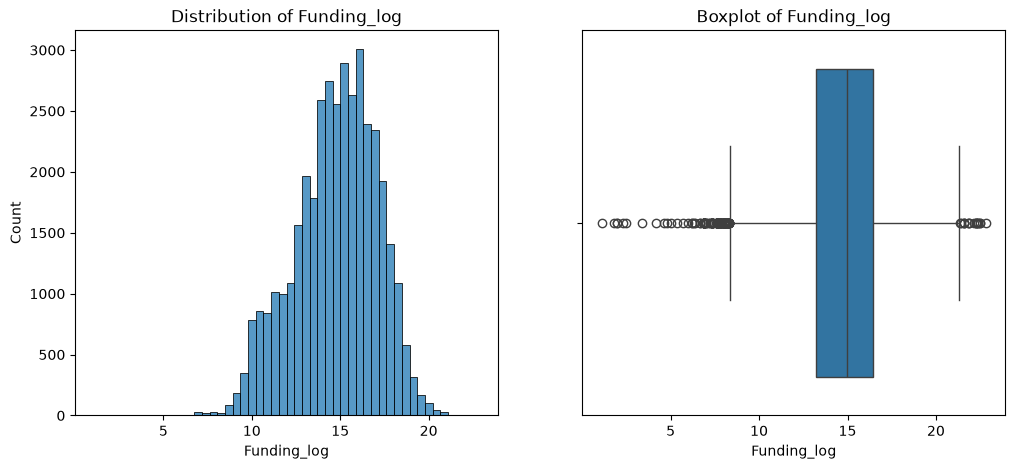

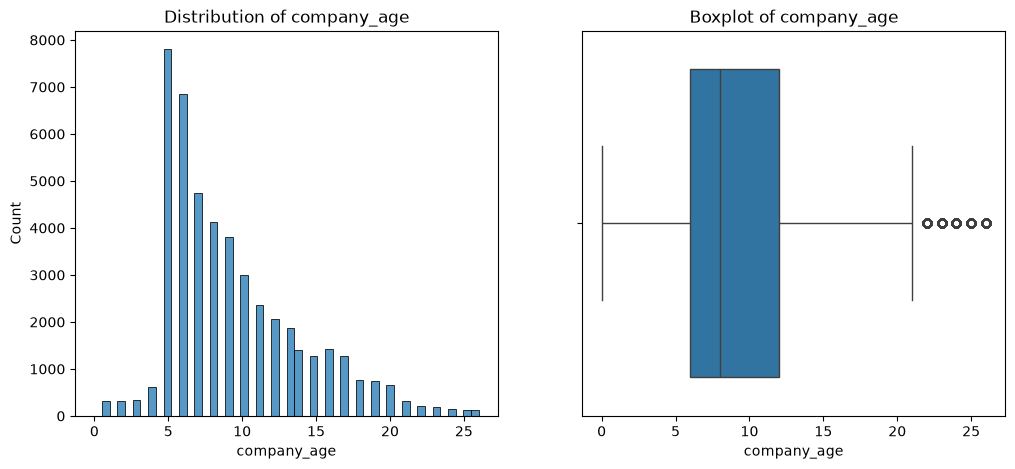

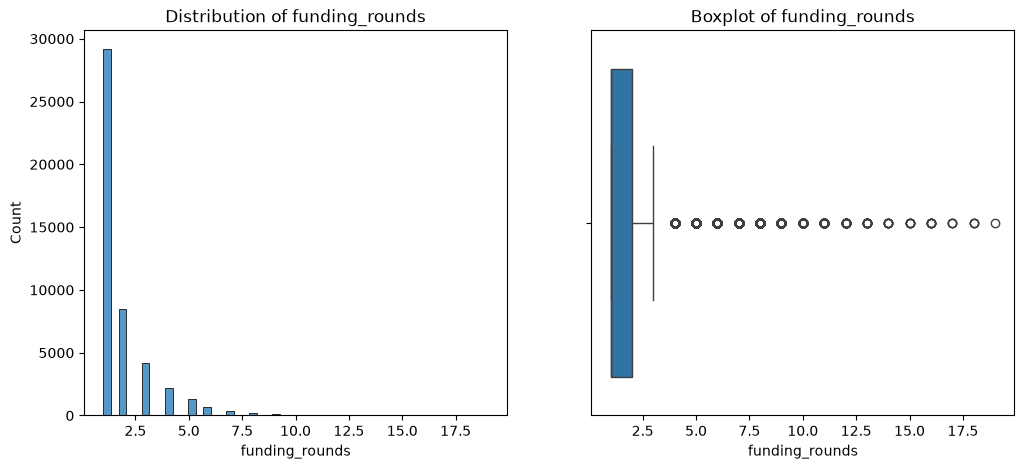

In [48]:
# Univariate plots for the main numeric features
df["Funding"] = pd.to_numeric(df["Funding"], errors="coerce")
df["Funding_log"] = np.log1p(df["Funding"])

num_cols = ["Funding_log", "company_age", "funding_rounds"]

for col in num_cols:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=50)
    plt.title(f"Distribution of {col}")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

    plt.show()


## Bivariate and grouped analysis


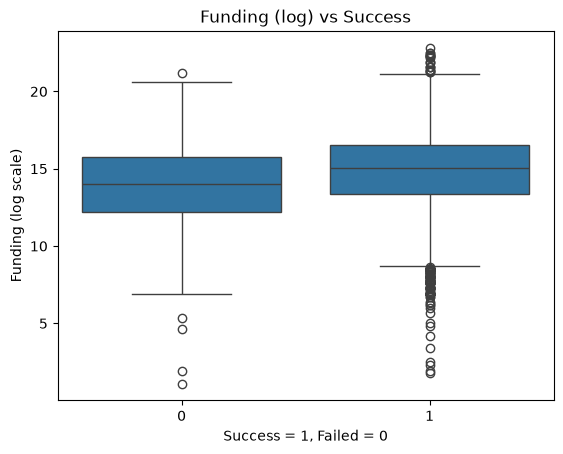

In [49]:
#Bi-variate plots 

#funding vs success
sns.boxplot(x = "success", y = "Funding_log", data = df)
plt.title("Funding (log) vs Success")
plt.xlabel("Success = 1, Failed = 0")
plt.ylabel("Funding (log scale)")
plt.show()

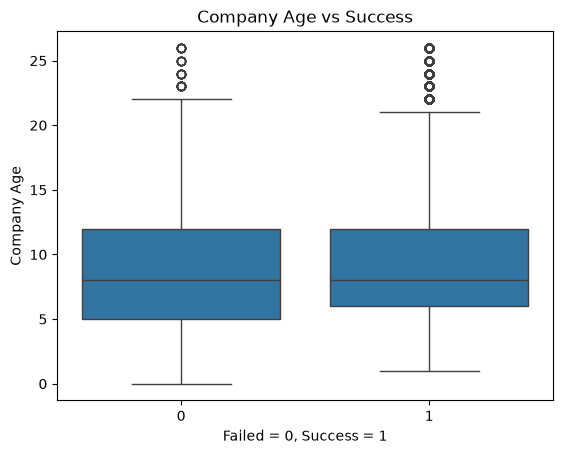

In [50]:
#Company Age vs success
sns.boxplot(x = "success", y = "company_age", data = df)
plt.title("Company Age vs Success")
plt.xlabel("Failed = 0, Success = 1")
plt.ylabel("Company Age")
plt.show()

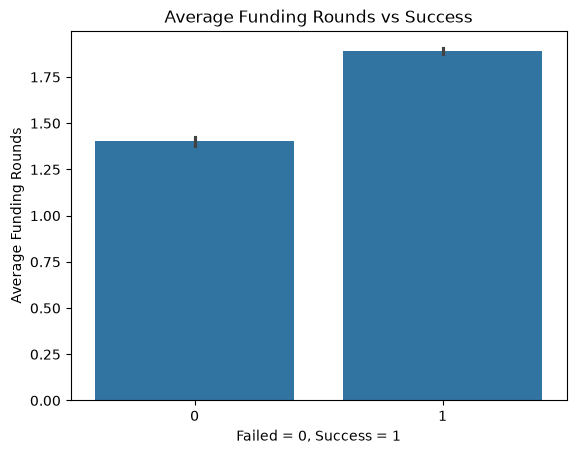

In [51]:
#funding rounds vs success 
sns.barplot(x='success', y='funding_rounds', data=df, estimator=np.mean)
plt.title("Average Funding Rounds vs Success")
plt.xlabel("Failed = 0, Success = 1")
plt.ylabel("Average Funding Rounds")
plt.show()

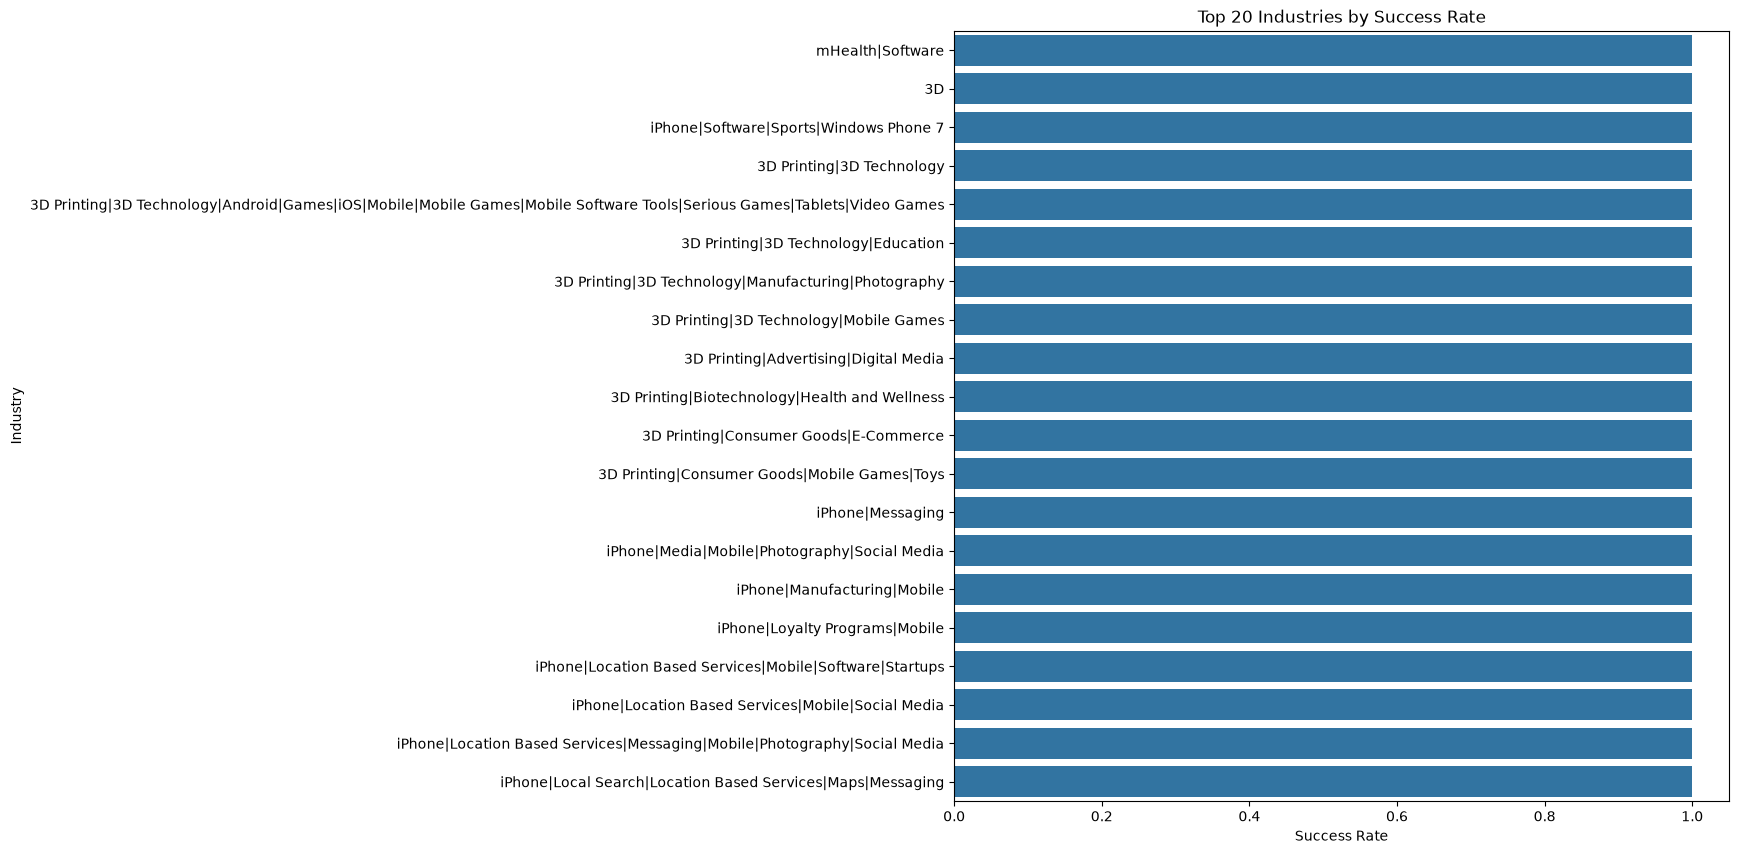

In [52]:
# Industry success rate
industry_success = (
    df.groupby("Industry")["success"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 10))
sns.barplot(x=industry_success.head(20), y=industry_success.head(20).index)
plt.title("Top 20 Industries by Success Rate")
plt.xlabel("Success Rate")
plt.ylabel("Industry")
plt.show()

# Some industry names are very rare, so this chart is mainly exploratory.


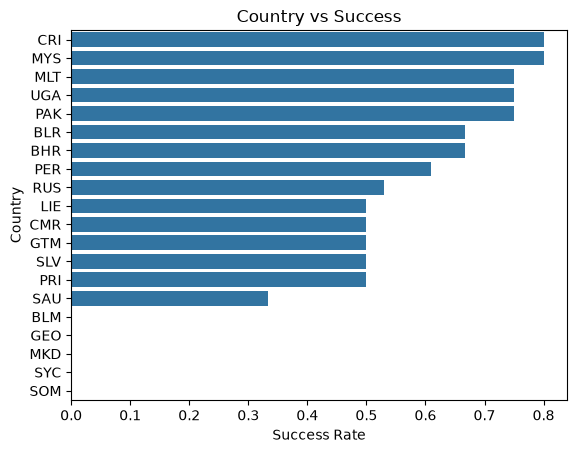

In [53]:
#we can do similar bar plot for countries
country_success = (
    df.groupby("country_code")["success"]
      .mean()
      .reset_index()
      .sort_values("success", ascending=False)
)
bottom10_countries = country_success.tail(20)

sns.barplot(x="success", y = "country_code", data = bottom10_countries)
plt.title("Country vs Success")
plt.xlabel("Success Rate")
plt.ylabel("Country")
plt.show()

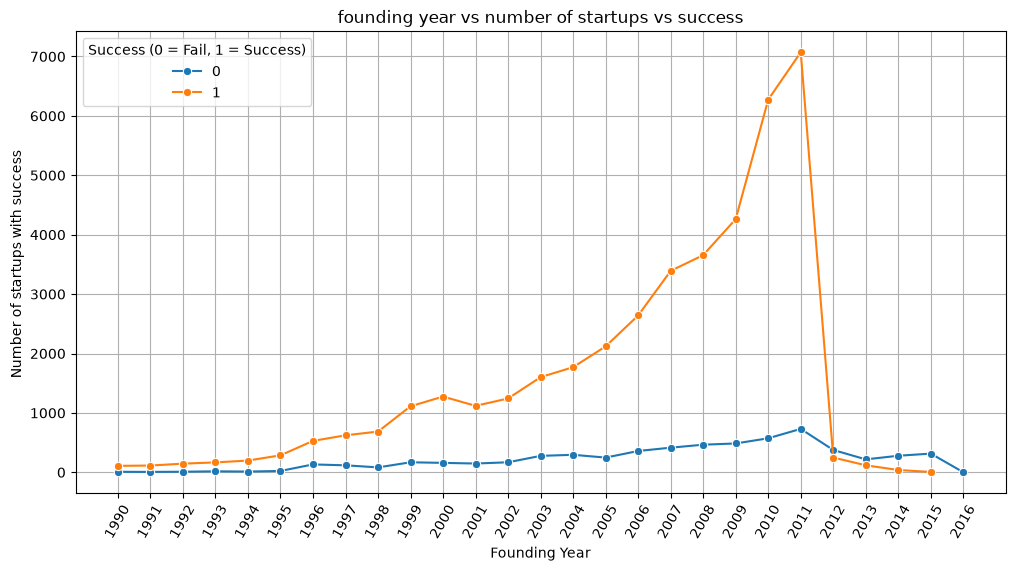

In [54]:
#founding year vs number of startups vs success

df["year_founded"] = df["Founding_year"].dt.year

yearly_counts = df.groupby(['year_founded', 'success']).size().reset_index(name='count')
min_year = df['year_founded'].min()
max_year = df['year_founded'].max()


plt.figure(figsize=(12,6))
#line plot for this
sns.lineplot(data = yearly_counts, x= 'year_founded', y= 'count', hue = 'success', marker = "o")
plt.xlabel("Founding Year")
plt.xticks(range(min_year, max_year+1, 1), rotation = 60)
plt.ylabel("Number of startups with success ")
plt.title("founding year vs number of startups vs success")
plt.grid(1)
plt.legend(title="Success (0 = Fail, 1 = Success)")
plt.show()

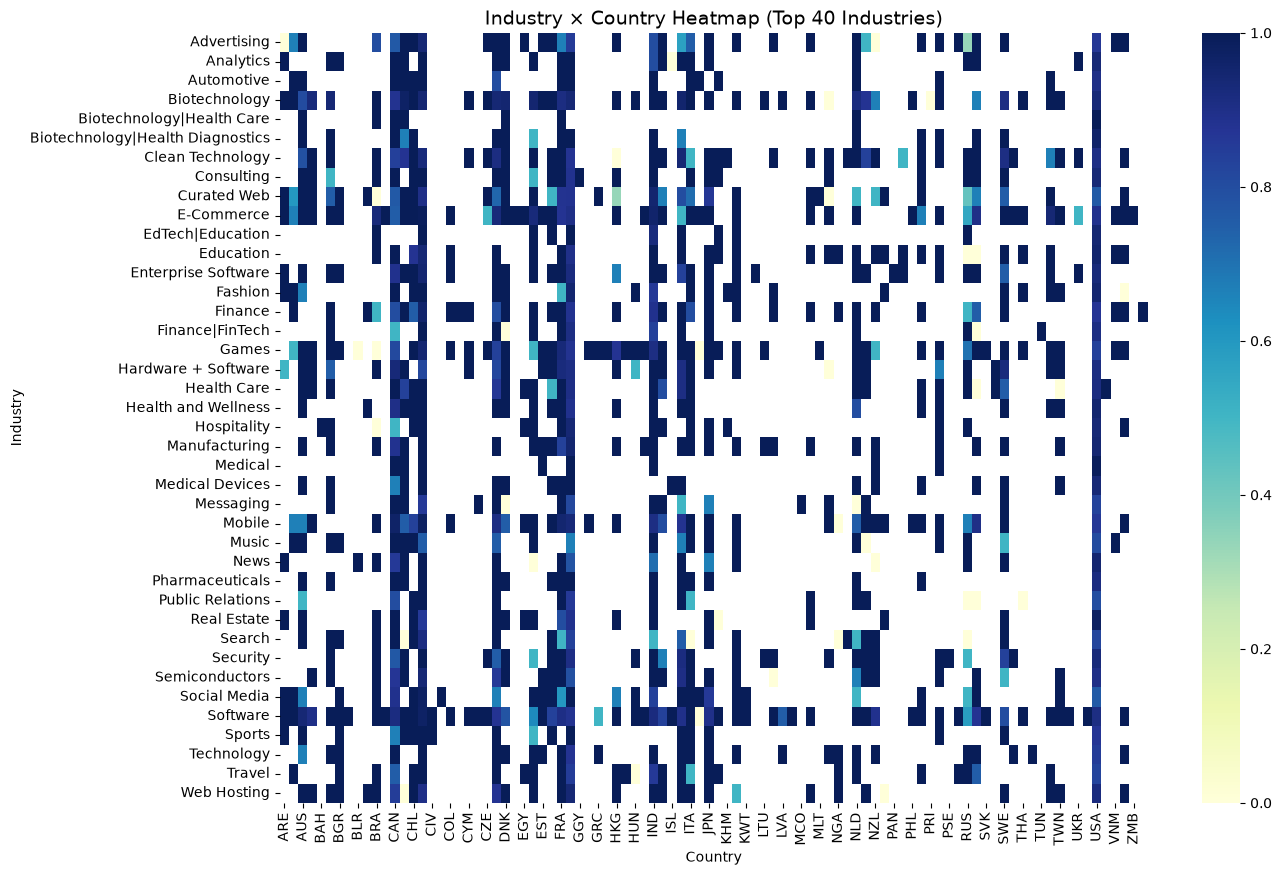

In [55]:
#Industry x Country

top_industries = df["Industry"].value_counts().head(40).index
df_top = df[df["Industry"].isin(top_industries)]

industry_country = df_top.pivot_table(
    index="Industry",
    columns="country_code",
    values="success",
    aggfunc="mean"
)

plt.figure(figsize=(14, 10))
sns.heatmap(industry_country, cmap="YlGnBu")
plt.title("Industry × Country Heatmap (Top 40 Industries)", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Industry")
plt.show()


In [56]:
#we have successfully completed the exploratory data analysis on this dataset and found out useful insights:
#we manipulated the dataset by adding and removing certain columns to match with our needs
#Here is the summary

## Prepare the processed dataset


In [57]:
df.info()

<class 'pandas.DataFrame'>
Index: 46903 entries, 0 to 66367
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   name               46902 non-null  str           
 1   Industry           44511 non-null  str           
 2   Funding            38467 non-null  float64       
 3   status             46903 non-null  str           
 4   country_code       41685 non-null  str           
 5   state_code         40654 non-null  str           
 6   region             40926 non-null  str           
 7   city               40928 non-null  str           
 8   funding_rounds     46903 non-null  int64         
 9   Founding_year      46903 non-null  datetime64[us]
 10  first_funding_at   46897 non-null  datetime64[us]
 11  last_funding_at    46903 non-null  str           
 12  funding_diff_days  32034 non-null  float64       
 13  company_age        46903 non-null  float64       
 14  success            469

In [58]:
df[(df['Funding'].isnull()) & (df['year_founded']>2012)].shape[0]

271

In [59]:
df.head()

,name,Industry,Funding,status,country_code,state_code,region,city,funding_rounds,Founding_year,first_funding_at,last_funding_at,funding_diff_days,company_age,success,Funding_log,year_founded
0,#fame,Media,10000000.0,operating,IND,16,Mumbai,Mumbai,1,2011-04-09,2015-01-05,2015-01-05,NaN,5.0,1,16.118096,2011
2,"(THE) ONE of THEM,Inc.",Apps|Games|Mobile,3406878.0,operating,NaN,NaN,NaN,NaN,1,2010-05-04,2014-01-30,2014-01-30,NaN,6.0,1,15.041307,2010
3,0-6.com,Curated Web,2000000.0,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19,443.0,9.0,1,14.508658,2007
4,004 Technologies,Software,NaN,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24,1665.0,6.0,1,NaN,2010
5,01Games Technology,Games,41250.0,operating,HKG,NaN,Hong Kong,Hong Kong,1,2010-10-03,2014-07-01,2014-07-01,NaN,6.0,1,10.627431,2010


In [60]:
cols_to_drop = ["funding_diff_days", "city", "state_code", "Founding_year", "first_funding_at", "last_funding_at"]

df = df.drop(columns = cols_to_drop, errors = "ignore")

df.head()

,name,Industry,Funding,status,country_code,region,funding_rounds,company_age,success,Funding_log,year_founded
0,#fame,Media,10000000.0,operating,IND,Mumbai,1,5.0,1,16.118096,2011
2,"(THE) ONE of THEM,Inc.",Apps|Games|Mobile,3406878.0,operating,NaN,NaN,1,6.0,1,15.041307,2010
3,0-6.com,Curated Web,2000000.0,operating,CHN,Beijing,1,9.0,1,14.508658,2007
4,004 Technologies,Software,NaN,operating,USA,"Springfield, Illinois",1,6.0,1,NaN,2010
5,01Games Technology,Games,41250.0,operating,HKG,Hong Kong,1,6.0,1,10.627431,2010


In [61]:
df["Funding"] = df["Funding"].fillna(0)

df["Funding_log"] = np.log1p(df["Funding"])
df.head(25)

,name,Industry,Funding,status,country_code,region,funding_rounds,company_age,success,Funding_log,year_founded
0,#fame,Media,1.000000e+07,operating,IND,Mumbai,1,5.0,1,16.118096,2011
2,"(THE) ONE of THEM,Inc.",Apps|Games|Mobile,3.406878e+06,operating,NaN,NaN,1,6.0,1,15.041307,2010
3,0-6.com,Curated Web,2.000000e+06,operating,CHN,Beijing,1,9.0,1,14.508658,2007
4,004 Technologies,Software,0.000000e+00,operating,USA,"Springfield, Illinois",1,6.0,1,0.000000,2010
5,01Games Technology,Games,4.125000e+04,operating,HKG,Hong Kong,1,6.0,1,10.627431,2010
6,Ondine Biomedical Inc.,Biotechnology,7.628510e+05,operating,CAN,Vancouver,2,19.0,1,13.544819,1997
7,H2O.ai,Analytics,3.360000e+07,operating,USA,SF Bay Area,4,5.0,1,17.330037,2011
8,One Inc.,Mobile,1.150050e+06,operating,USA,SF Bay Area,3,5.0,1,13.955317,2011
10,1-4 All,Entertainment|Games|Software,0.000000e+00,operating,USA,NC - Other,1,7.0,1,0.000000,2009
15,1 Mainstream,Apps|Cable|Distribution|Software,5.000000e+06,acquired,USA,SF Bay Area,1,4.0,1,15.424949,2012


In [62]:
#now we should proceed towards industry cleaning part because its overly complicated

df["Industry"].value_counts().head(20)


Industry
Biotechnology          3229
Software               3218
Clean Technology       1011
E-Commerce              975
Mobile                  969
Curated Web             881
Hardware + Software     820
Health Care             795
Enterprise Software     753
Games                   742
Manufacturing           631
Health and Wellness     615
Advertising             587
Semiconductors          456
Finance                 352
Security                350
Education               344
Web Hosting             334
Social Media            308
Consulting              294
Name: count, dtype: int64

In [63]:
#we will proceed with top N industries and categorize everything else as Other
#here we are taking N=20 

Top_N = 14

top_industries = (df["Industry"].value_counts().nlargest(Top_N).index)

df["Industry_clean"] = df["Industry"].where(
    df["Industry"].isin(top_industries),
    "Other"
)

df["Industry_clean"].value_counts()


Industry_clean
Other                  31221
Biotechnology           3229
Software                3218
Clean Technology        1011
E-Commerce               975
Mobile                   969
Curated Web              881
Hardware + Software      820
Health Care              795
Enterprise Software      753
Games                    742
Manufacturing            631
Health and Wellness      615
Advertising              587
Semiconductors           456
Name: count, dtype: int64

## Export for modeling


In [64]:
# Export the cleaned dataset for the modeling notebook
df.to_csv(
    r"C:\Users\mklad\Desktop\Startup_Investment_App\Data\processed\processed_dataset.csv",
    index=False
)

print("Processed dataset saved successfully.")


Processed dataset saved successfully.
